In [ ]:
import pandas as pd #loading data
import numpy as np # math calculations
import re #regular expressions for cleaning data
import matplotlib.pyplot as plt
import nltk # for all basic operations
from nltk.corpus import stopwords #large set of data, collections documents to
#to remove unwanted words-> stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

#Download required NLTK files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

In [ ]:
df.head()

,Review
0,The product quality is excellent and delivery ...
1,Very bad packaging and the item was damaged.
2,Customer service was helpful and responsive.
3,The delivery was delayed and support team did ...
4,Amazing product. Worth the money.


In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
  #convert to lowercase
  text = text.lower()
  print('lower case',text)

 #rempove special characters and numbers
  text = re.sub(r'[^a-zA-Z\s]','',text)
  print('special characters',text)

 #Tokenization
  words = word_tokenize(text)
  print('tokenization',words)

 #remove stopwords
  words=[word for word in words if word not in stop_words]
  print('stopwords',words)

 #join words again
  cleaned_text = " ".join(words)
  return cleaned_text


In [ ]:
#apply cleaning function
df['Cleaned_Review'] = df['Review'].apply(clean_text)

print("\nCleaned Reviews")
print(df[['Review','Cleaned_Review']])


lower case the product quality is excellent and delivery was very fast.
special characters the product quality is excellent and delivery was very fast
tokenization ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']
stopwords ['product', 'quality', 'excellent', 'delivery', 'fast']
lower case very bad packaging and the item was damaged.
special characters very bad packaging and the item was damaged
tokenization ['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']
stopwords ['bad', 'packaging', 'item', 'damaged']
lower case customer service was helpful and responsive.
special characters customer service was helpful and responsive
tokenization ['customer', 'service', 'was', 'helpful', 'and', 'responsive']
stopwords ['customer', 'service', 'helpful', 'responsive']
lower case the delivery was delayed and support team did not respond.
special characters the delivery was delayed and support team did not respond
tokenization ['the', 'deliv

STEP 4 :SENTIMENT ANALYSIS
**bold text**

In [ ]:
sia = SentimentIntensityAnalyzer()
def analyze_sentiment(review):
  score = sia.polarity_scores(review)
  compound = score['compound']

  if compound >= 0.05:
    return 'Positive'
  elif compound <= -0.05:
    return'Negative'
  else:
      return 'Neutral'

#Apply sentiment analysis
df['Sentiment']=df["Cleaned_Review"].apply(analyze_sentiment)
print("\nSentiment Analysis")
print(df[['Review','Sentiment']])



Sentiment Analysis
                                              Review Sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                  Amazing product. Worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


STEP5: FIND COMMON KEYWORDS

In [ ]:
all_words= " ".join(df['Cleaned_Review'])
word_list = all_words.split()

#count word frequency
word_freq= Counter(word_list)
#display the top 10 keywords
print("\nTop 10 Keywords")
print(word_freq.most_common(10))


Top 10 Keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


STEP6: IDENTIFY COMMON COMPLAINTS

In [ ]:
negative_reviews = df[df['Sentiment']== 'Negative']
negative_words=" ".join(negative_reviews['Cleaned_Review'])
negative_word_list = negative_words.split()
complaint_freq = Counter(negative_word_list)

print("\nMost common complaint keywords")
print(complaint_freq.most_common(10))


Most common complaint keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


STEP7: VISULAIZATION-SENTIMENT COUNT

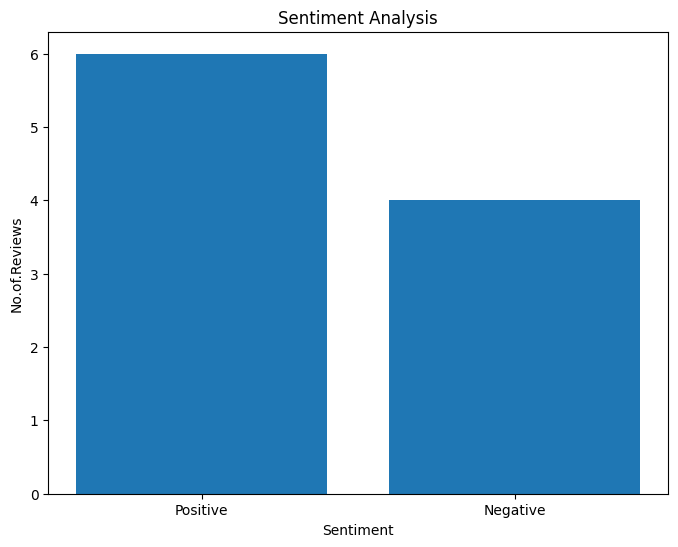

In [ ]:
sentiment_counts=df['Sentiment'].value_counts()# gives category counts

plt.figure(figsize=(8,6))
plt.bar(sentiment_counts.index,sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('No.of.Reviews')
plt.title('Sentiment Analysis')
plt.show()

STEP8: GENERATE WORD CLOUD

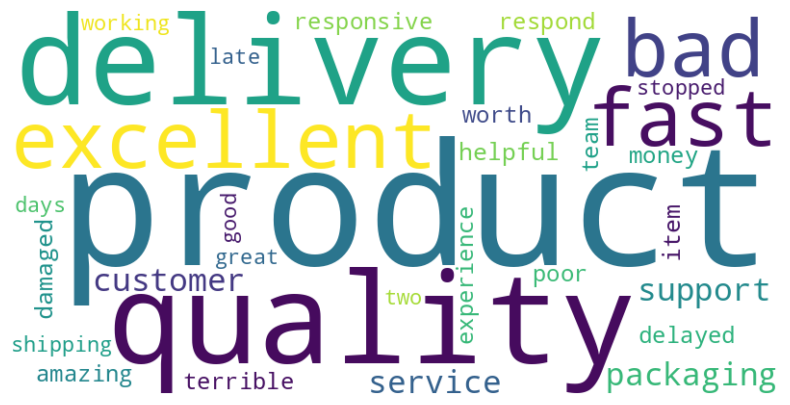

In [ ]:
wordcloud= WordCloud(
    width=800,
    height=400,
    bdsackground_color='white'
).generate(all_words)

plt.figure(figsize=( 10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()